### Imporing the necessary Libraries.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



#### And Here I have imported the iris dataset and MinMax Scaler for some preprocessing.

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler


In [4]:
iris=load_iris()

In [5]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#### I have dropped two columns for simplicity

In [6]:
df.drop(['sepal length (cm)','sepal width (cm)'],axis=1,inplace=True)

In [7]:
df

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [8]:
df.shape

(150, 2)

#### A scatter plot visit the datasets 

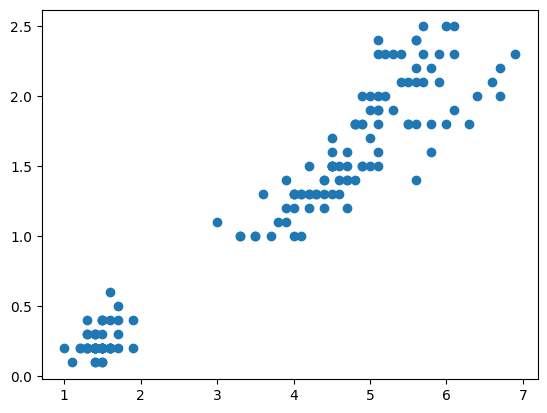

In [9]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])

#### Scaled the data for better clustering.

In [24]:
scaler=MinMaxScaler()
df["petal length (cm)"]=scaler.fit_transform(df[["petal length (cm)"]])
df["petal width (cm)"]=scaler.fit_transform(df[["petal width (cm)"]])

In [27]:
km=KMeans(n_clusters=3)
y_pred=km.fit_predict(df[["petal length (cm)","petal width (cm)"]])
df["cluster"]=y_pred



#### Visulaizing the Clusters using matplotlib

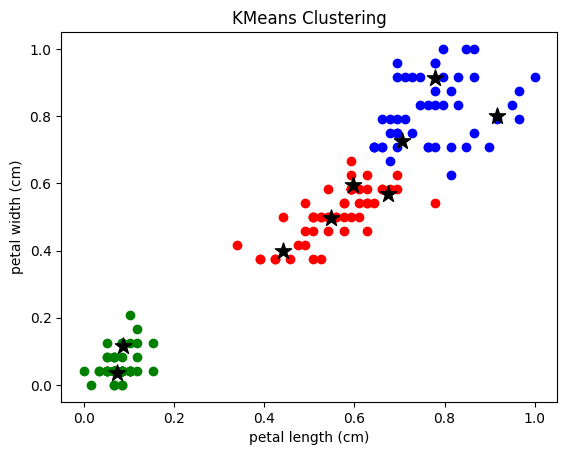

In [35]:
df1=df[df["cluster"]==0]
df2=df[df["cluster"]==1]
df3=df[df["cluster"]==2]

plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],color="green")
plt.scatter(df2["petal length (cm)"],df2["petal width (cm)"],color="red")
plt.scatter(df3["petal length (cm)"],df3["petal width (cm)"],color="blue")

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="black",marker="*",s=150)

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("KMeans Clustering")
plt.show()

##### A small code to check the elbow graph, In which we also get to know the correct no of cluster we need to use.

In [28]:
k_range=range(1,10)
SSE=[]
for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df)
    SSE.append(km.inertia_)

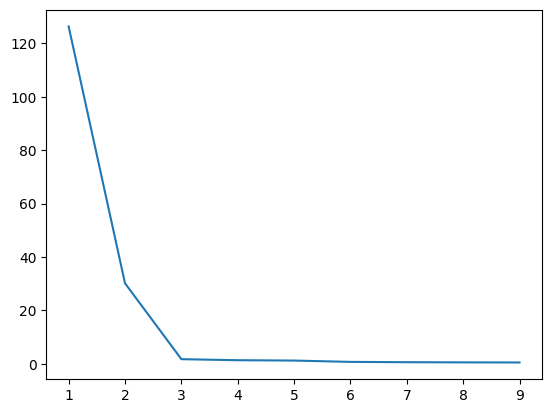

In [29]:
plt.plot(k_range,SSE)